# TT-04 — Logistic Regression

## Dự đoán nguy cơ bệnh tim

Mục tiêu:
- Xây dựng mô hình Logistic Regression.
- Dự đoán nguy cơ mắc bệnh tim.
- Giải thích mô hình bằng Odds Ratio.
- Đánh giá mô hình bằng Recall, Precision, ROC-AUC.
- Tìm ngưỡng dự đoán phù hợp với yêu cầu Recall >= 0.90.

Đọc và làm sạch dữ liệu

In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

print("Import thư viện thành công!")

Import thư viện thành công!


In [4]:
# Đọc dữ liệu
df = pd.read_csv(
    r"D:\TT_ML\TT-04-LogisticRegression_Linh\dataset\heart.csv"
)

print("Kích thước ban đầu:", df.shape)

# Kiểm tra số dòng trùng
duplicate_count = df.duplicated().sum()

print("Số dòng trùng:", duplicate_count)

# Xóa dòng trùng
df = df.drop_duplicates()

print("Kích thước sau khi xóa duplicate:", df.shape)

# Kiểm tra lại
print("Số duplicate còn lại:", df.duplicated().sum())

# Xem 5 dòng đầu
display(df.head())

Kích thước ban đầu: (1025, 14)
Số dòng trùng: 723
Kích thước sau khi xóa duplicate: (302, 14)
Số duplicate còn lại: 0


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


Xác định biến

In [5]:
# Biến phân loại → One-Hot Encoding
categorical_columns = [
    "cp",
    "restecg",
    "slope",
    "thal",
    "ca"
]

# Biến số → StandardScaler
numeric_columns = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

# Biến mục tiêu
target_column = "target"

# Tách X và y
X = df.drop(columns=[target_column])
y = df[target_column]

print("Biến phân loại:", categorical_columns)
print("Biến số:", numeric_columns)
print("Biến mục tiêu:", target_column)

print("\nKích thước X:", X.shape)
print("Kích thước y:", y.shape)

Biến phân loại: ['cp', 'restecg', 'slope', 'thal', 'ca']
Biến số: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Biến mục tiêu: target

Kích thước X: (302, 13)
Kích thước y: (302,)


EDA

TỈ LỆ BỆNH THEO CP
cp
0    0.272727
1    0.820000
2    0.790698
3    0.695652
Name: target, dtype: float64


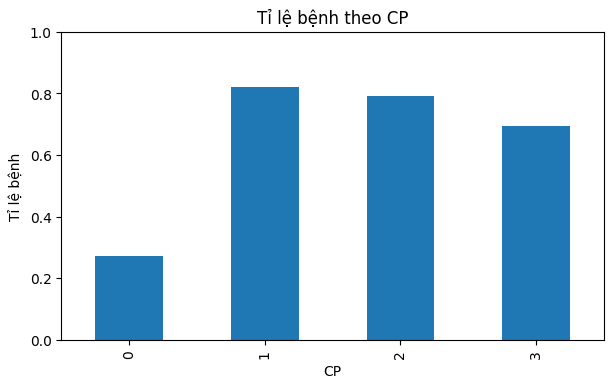


TỈ LỆ BỆNH THEO NHÓM TUỔI
age_group
<40      0.733333
40-49    0.694444
50-59    0.520000
60-69    0.400000
70+      0.600000
Name: target, dtype: float64


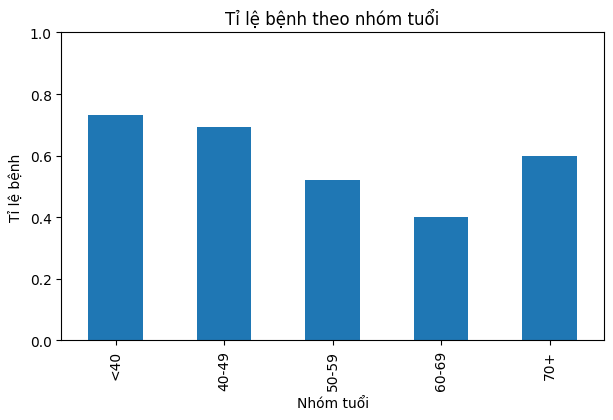

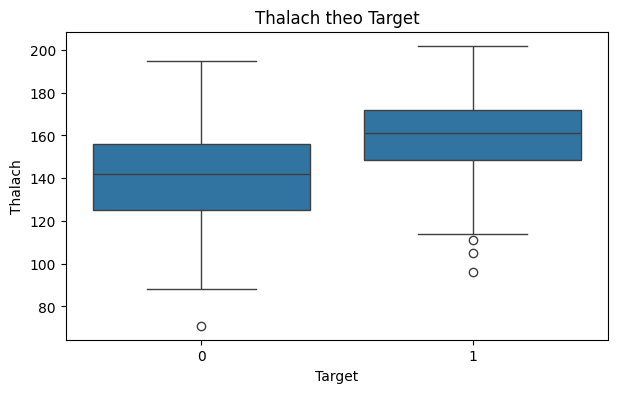

In [6]:
#TỈ LỆ BỆNH THEO CP 

cp_rate = df.groupby("cp")["target"].mean()

print("TỈ LỆ BỆNH THEO CP")
print(cp_rate)

cp_rate.plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("Tỉ lệ bệnh theo CP")
plt.xlabel("CP")
plt.ylabel("Tỉ lệ bệnh")
plt.ylim(0, 1)
plt.show()


#TỈ LỆ BỆNH THEO NHÓM TUỔI

df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 39, 49, 59, 69, 100],
    labels=["<40", "40-49", "50-59", "60-69", "70+"]
)

age_rate = df.groupby(
    "age_group",
    observed=False
)["target"].mean()

print("\nTỈ LỆ BỆNH THEO NHÓM TUỔI")
print(age_rate)

age_rate.plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("Tỉ lệ bệnh theo nhóm tuổi")
plt.xlabel("Nhóm tuổi")
plt.ylabel("Tỉ lệ bệnh")
plt.ylim(0, 1)
plt.show()


#BOXPLOT THALACH THEO TARGET 

plt.figure(figsize=(7, 4))

sns.boxplot(
    data=df,
    x="target",
    y="thalach"
)

plt.title("Thalach theo Target")
plt.xlabel("Target")
plt.ylabel("Thalach")

plt.show()

PIPELINE

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Bỏ age_group vì chỉ dùng cho EDA
X = df.drop(columns=["target", "age_group"])
y = df["target"]

# Chia Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Xử lý biến phân loại và biến số
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_columns
        ),
        (
            "numeric",
            StandardScaler(),
            numeric_columns
        )
    ]
)

# Tạo Pipeline
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

# Train model
logistic_pipeline.fit(
    X_train,
    y_train
)

print("Train Logistic Regression thành công!")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

Train Logistic Regression thành công!
X_train: (241, 13)
X_test: (61, 13)


BASELINE (Dummy Classifier)

In [8]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Tạo baseline
dummy_model = DummyClassifier(
    strategy="most_frequent"
)

# Train
dummy_model.fit(
    X_train,
    y_train
)

# Dự đoán
dummy_pred = dummy_model.predict(X_test)

# Đánh giá
print("DUMMY CLASSIFIER")
print("-------------------------")

print(
    "Accuracy:",
    accuracy_score(y_test, dummy_pred)
)

print(
    "Precision:",
    precision_score(
        y_test,
        dummy_pred,
        zero_division=0
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        dummy_pred,
        zero_division=0
    )
)

DUMMY CLASSIFIER
-------------------------
Accuracy: 0.5409836065573771
Precision: 0.5409836065573771
Recall: 1.0


Train, in bảng ODDS RATIO xếp hạng

In [9]:
# Dự đoán
y_pred = logistic_pipeline.predict(X_test)

# Xác suất bệnh
y_probability = logistic_pipeline.predict_proba(
    X_test
)[:, 1]

# Đánh giá
print("LOGISTIC REGRESSION")
print("-------------------------")

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred)
)

print(
    "Precision:",
    precision_score(y_test, y_pred)
)

print(
    "Recall:",
    recall_score(y_test, y_pred)
)


# ----- ODDS RATIO -----

trained_model = logistic_pipeline.named_steps["model"]

coefficients = trained_model.coef_[0]

feature_names = (
    logistic_pipeline
    .named_steps["preprocessing"]
    .get_feature_names_out()
)

odds_ratio = np.exp(coefficients)

odds_table = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Odds_Ratio": odds_ratio
})

odds_table = odds_table.sort_values(
    "Odds_Ratio",
    ascending=False
)

print("\nBẢNG ODDS RATIO")

display(odds_table)

LOGISTIC REGRESSION
-------------------------
Accuracy: 0.7704918032786885
Precision: 0.7878787878787878
Recall: 0.7878787878787878

BẢNG ODDS RATIO


,Feature,Coefficient,Odds_Ratio
14,categorical__ca_0,1.408703,4.090646
12,categorical__thal_2,0.834891,2.304562
2,categorical__cp_2,0.813139,2.254975
22,numeric__thalach,0.708809,2.031570
18,categorical__ca_4,0.598905,1.820124
3,categorical__cp_3,0.556625,1.744774
9,categorical__slope_2,0.354847,1.425963
19,numeric__age,0.337928,1.402039
11,categorical__thal_1,0.285299,1.330160
5,categorical__restecg_1,0.241083,1.272627


So sánh L1 và L2

In [10]:
# Logistic Regression L1
model_l1 = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        (
            "model",
            LogisticRegression(
                penalty="l1",
                solver="liblinear",
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

# Logistic Regression L2
model_l2 = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        (
            "model",
            LogisticRegression(
                penalty="l2",
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

# Train
model_l1.fit(X_train, y_train)
model_l2.fit(X_train, y_train)

# Dự đoán
pred_l1 = model_l1.predict(X_test)
pred_l2 = model_l2.predict(X_test)

# Tính điểm
print("L1")
print("Accuracy:", accuracy_score(y_test, pred_l1))
print("Precision:", precision_score(y_test, pred_l1))
print("Recall:", recall_score(y_test, pred_l1))

print("\nL2")
print("Accuracy:", accuracy_score(y_test, pred_l2))
print("Precision:", precision_score(y_test, pred_l2))
print("Recall:", recall_score(y_test, pred_l2))


# Đếm hệ số bằng 0 của L1
coef_l1 = model_l1.named_steps["model"].coef_[0]

zero_count = np.sum(
    np.isclose(coef_l1, 0)
)

print("\nSố feature L1 loại về 0:", zero_count)

L1
Accuracy: 0.7704918032786885
Precision: 0.7878787878787878
Recall: 0.7878787878787878

L2
Accuracy: 0.7704918032786885
Precision: 0.7878787878787878
Recall: 0.7878787878787878

Số feature L1 loại về 0: 8


c:\Users\lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default

Vẽ đường ROC và Precision-Recall

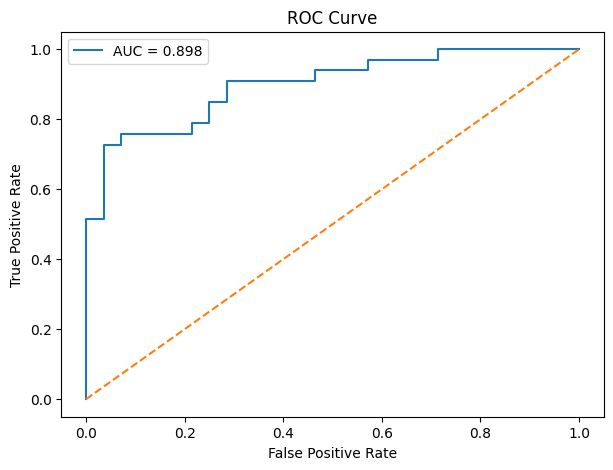

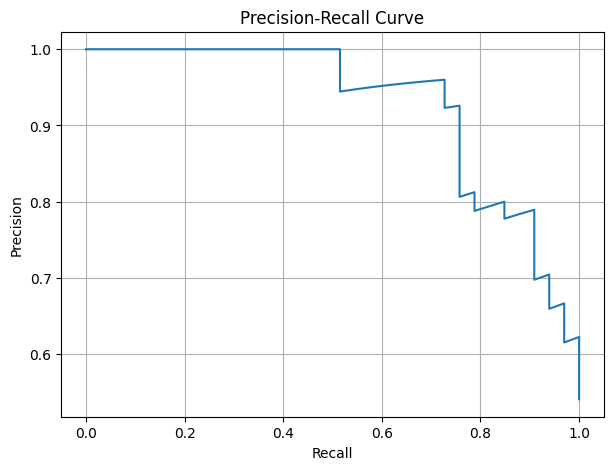

ROC-AUC: 0.8982683982683983


In [11]:
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    precision_recall_curve
)

# ----- ROC -----

auc = roc_auc_score(
    y_test,
    y_probability
)

fpr, tpr, roc_thresholds = roc_curve(
    y_test,
    y_probability
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()


# ----- PRECISION-RECALL -----

precision_values, recall_values, pr_thresholds = (
    precision_recall_curve(
        y_test,
        y_probability
    )
)

plt.figure(figsize=(7, 5))

plt.plot(
    recall_values,
    precision_values
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.grid()
plt.show()

print("ROC-AUC:", auc)

Chọn ngưỡng đạt recall ≥ 0,90, ghi lại precision tương ứng

In [12]:
target_recall = 0.90

best_threshold = None
best_precision = None
best_recall = None

# Tìm threshold đầu tiên đạt Recall >= 0.90
for i in range(len(pr_thresholds)):

    if recall_values[i] >= target_recall:

        best_threshold = pr_thresholds[i]
        best_precision = precision_values[i]
        best_recall = recall_values[i]

        break

print("Threshold:", best_threshold)
print("Recall:", best_recall)
print("Precision:", best_precision)


# Dự đoán với threshold mới
y_pred_threshold = (
    y_probability >= best_threshold
).astype(int)

print("\nKIỂM TRA LẠI")
print(
    "Precision:",
    precision_score(
        y_test,
        y_pred_threshold
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        y_pred_threshold
    )
)

Threshold: 0.002085005002516454
Recall: 1.0
Precision: 0.5409836065573771

KIỂM TRA LẠI
Precision: 0.5409836065573771
Recall: 1.0


Kiểm tra ĐA CỘNG TUYẾN bằng VIF → biến nào VIF > 10?

In [13]:
import sys

!{sys.executable} -m pip install statsmodels


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
import statsmodels

print("Statsmodels:", statsmodels.__version__)
print("Đường dẫn:", statsmodels.__file__)

Statsmodels: 0.14.6
Đường dẫn: c:\Users\lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\__init__.py


In [16]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Đưa dữ liệu qua preprocessing
X_vif = preprocessor.fit_transform(X_train)

# Nếu là sparse matrix thì chuyển thành array
if hasattr(X_vif, "toarray"):
    X_vif = X_vif.toarray()

# Lấy tên feature
vif_features = preprocessor.get_feature_names_out()

# Tính VIF
vif_table = pd.DataFrame({
    "Feature": vif_features,
    "VIF": [
        variance_inflation_factor(
            X_vif,
            i
        )
        for i in range(X_vif.shape[1])
    ]
})

# Sắp xếp giảm dần
vif_table = vif_table.sort_values(
    "VIF",
    ascending=False
)

print("BẢNG VIF")
display(vif_table)

print("\nCÁC FEATURE CÓ VIF > 10")

display(
    vif_table[vif_table["VIF"] > 10]
)

BẢNG VIF


c:\Users\lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Feature,VIF
0,categorical__cp_0,inf
1,categorical__cp_1,inf
2,categorical__cp_2,inf
3,categorical__cp_3,inf
4,categorical__restecg_0,inf
5,categorical__restecg_1,inf
6,categorical__restecg_2,inf
7,categorical__slope_0,inf
8,categorical__slope_1,inf
9,categorical__slope_2,inf



CÁC FEATURE CÓ VIF > 10


,Feature,VIF
0,categorical__cp_0,inf
1,categorical__cp_1,inf
2,categorical__cp_2,inf
3,categorical__cp_3,inf
4,categorical__restecg_0,inf
5,categorical__restecg_1,inf
6,categorical__restecg_2,inf
7,categorical__slope_0,inf
8,categorical__slope_1,inf
9,categorical__slope_2,inf


So sánh 3 mô hình

In [17]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Tạo mô hình
svm = Pipeline([
    ("preprocessing", preprocessor),
    ("model", SVC(probability=True, random_state=42))
])

rf = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(n_estimators=200, random_state=42))
])

# Train
svm.fit(X_train, y_train)
rf.fit(X_train, y_train)

# Dự đoán
models = {
    "Logistic Regression": logistic_pipeline,
    "SVM": svm,
    "Random Forest": rf
}

results = []

for name, model in models.items():
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]

    results.append([
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred, zero_division=0),
        recall_score(y_test, pred, zero_division=0),
        f1_score(y_test, pred, zero_division=0),
        roc_auc_score(y_test, prob)
    ])

comparison = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
)

display(comparison)

c:\Users\lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.770492,0.787879,0.787879,0.787879,0.898268
1,SVM,0.770492,0.787879,0.787879,0.787879,0.874459
2,Random Forest,0.786885,0.777778,0.848485,0.811594,0.868506


Viết giải thích cho một bệnh nhân cụ thể

In [18]:
# Chọn bệnh nhân đầu tiên trong tập test
patient = X_test.iloc[[0]]

# Dự đoán xác suất mắc bệnh
prob = logistic_pipeline.predict_proba(patient)[0, 1]

# Dự đoán lớp
prediction = logistic_pipeline.predict(patient)[0]

print("THÔNG TIN BỆNH NHÂN:")
display(patient)

print("\nXác suất mắc bệnh:", round(prob * 100, 2), "%")

if prediction == 1:
    print("KẾT LUẬN: Mô hình dự đoán bệnh nhân CÓ nguy cơ mắc bệnh.")
else:
    print("KẾT LUẬN: Mô hình dự đoán bệnh nhân KHÔNG có nguy cơ mắc bệnh.")

THÔNG TIN BỆNH NHÂN:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
25,61,0,0,145,307,0,0,146,1,1.0,1,0,3



Xác suất mắc bệnh: 14.12 %
KẾT LUẬN: Mô hình dự đoán bệnh nhân KHÔNG có nguy cơ mắc bệnh.


Tạo Reports

✓ Đã lưu vif_table.csv


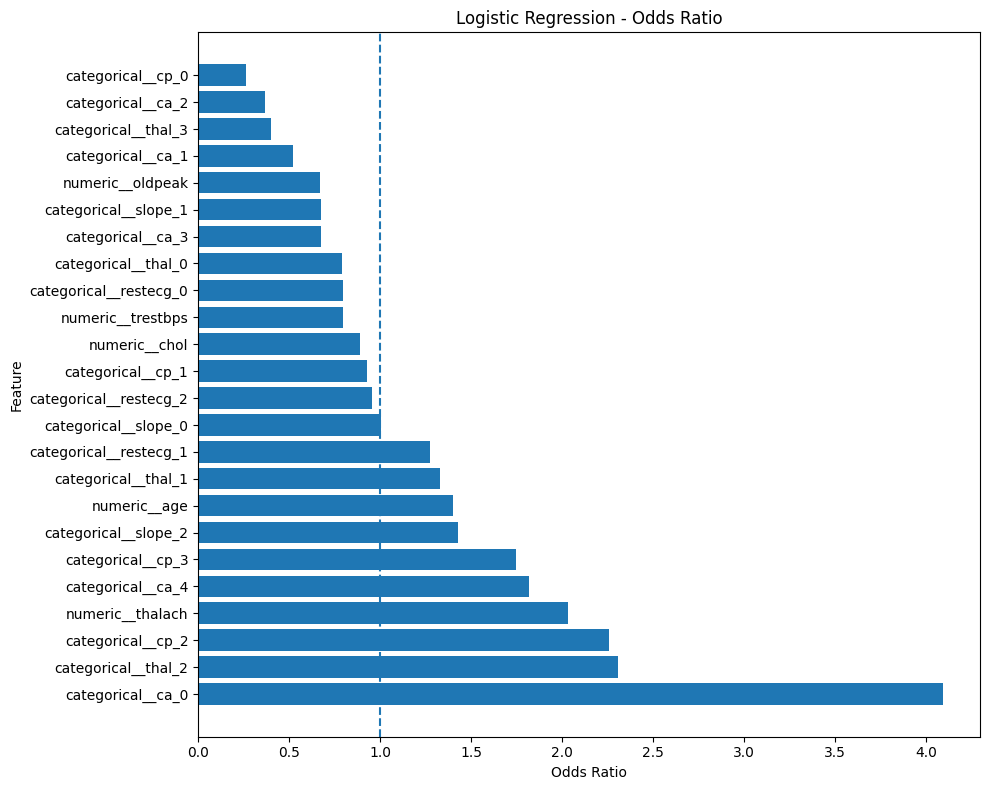

✓ Đã lưu odds_ratio.png


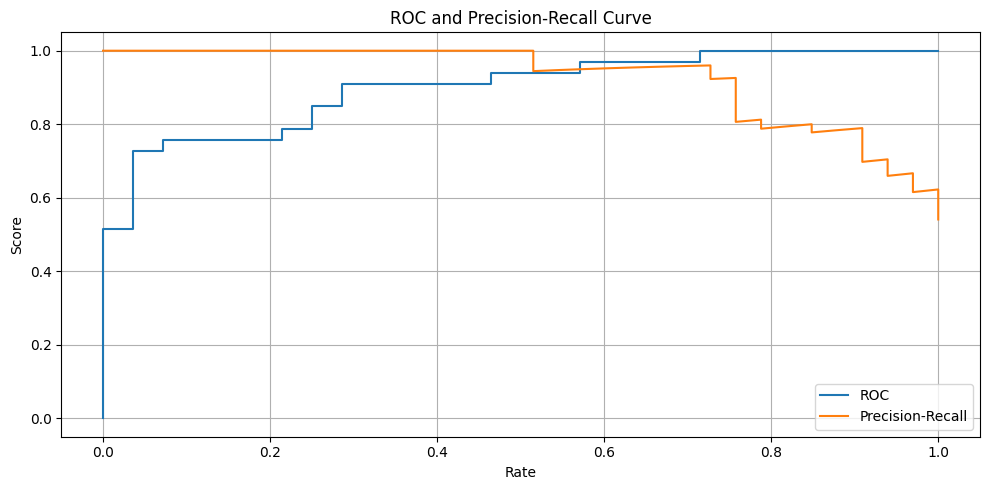

✓ Đã lưu roc_pr_curve.png

ĐÃ TẠO XONG REPORTS:
1. reports/vif_table.csv
2. reports/odds_ratio.png
3. reports/roc_pr_curve.png


In [23]:
import os
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve

# LƯU VIF

vif_table.to_csv(
    "reports/vif_table.csv",
    index=False
)

print("✓ Đã lưu vif_table.csv")
#  LƯU ODDS RATIO

# Lấy tên feature sau preprocessing
feature_names = logistic_pipeline.named_steps[
    "preprocessing"
].get_feature_names_out()

# Lấy hệ số Logistic Regression
coefficients = logistic_pipeline.named_steps[
    "model"
].coef_[0]

# Tính Odds Ratio
odds_ratio = np.exp(coefficients)

# Tạo bảng
odds_table = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Odds_Ratio": odds_ratio
})

# Sắp xếp theo Odds Ratio
odds_table = odds_table.sort_values(
    "Odds_Ratio",
    ascending=False
)

# Vẽ biểu đồ
plt.figure(figsize=(10, 8))

plt.barh(
    odds_table["Feature"],
    odds_table["Odds_Ratio"]
)

plt.axvline(
    1,
    linestyle="--"
)

plt.xlabel("Odds Ratio")
plt.ylabel("Feature")
plt.title("Logistic Regression - Odds Ratio")

plt.tight_layout()

plt.savefig(
    "reports/odds_ratio.png",
    dpi=300
)

plt.show()

print("✓ Đã lưu odds_ratio.png")
# 3. LƯU ROC + PRECISION-RECALL

# Xác suất dự đoán
y_prob = logistic_pipeline.predict_proba(
    X_test
)[:, 1]


# ROC
fpr, tpr, _ = roc_curve(
    y_test,
    y_prob
)


# Precision-Recall
precision, recall, _ = precision_recall_curve(
    y_test,
    y_prob
)


# Vẽ
plt.figure(figsize=(10, 5))

plt.plot(
    fpr,
    tpr,
    label="ROC"
)

plt.plot(
    recall,
    precision,
    label="Precision-Recall"
)

plt.xlabel("Rate")
plt.ylabel("Score")
plt.title("ROC and Precision-Recall Curve")

plt.legend()

plt.grid()

plt.tight_layout()

plt.savefig(
    "reports/roc_pr_curve.png",
    dpi=300
)

plt.show()

print("✓ Đã lưu roc_pr_curve.png")


# ==========================================
# HOÀN THÀNH
# ==========================================

print("\nĐÃ TẠO XONG REPORTS:")
print("1. reports/vif_table.csv")
print("2. reports/odds_ratio.png")
print("3. reports/roc_pr_curve.png")